In [1]:
import numpy as np 
import pandas as pd
import re

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [4]:
df.duplicated().sum()

122

In [5]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,on request,sector 103,1.69,9146.0,1848.0,Super Built up area 1845(171.41 sq.m.),3,3,3+,not available,8.0,NaN,1 to 5 Year Old,"['State bank ATM', 'Dr. Hitesh Dawar', 'Bhardwaj Hospital', 'R K Hospital Gurgaon', 'Shree Krishna Hospital Gurgaon', 'Prateek Nursing Home And Polyclinic', 'Chirag Hospital Pvt. Ltd', 'Esic Hospital Gurugram', 'Kr Dental Hub', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'Pizza Hut', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station', 'Basai dhankot railway station']","['3 Wardrobe', '6 Fan', '10 Light', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"


# 1. areaWithType

In [6]:
df.sample(5)[["price", "area", 'areaWithType']]

,price,area,areaWithType
2422,9.54,3240.0,Plot area 360(301.01 sq.m.)
2057,0.93,1530.0,Super Built up area 1283(119.19 sq.m.)
1031,0.50,650.0,Super Built up area 546(50.73 sq.m.)
2391,1.20,1240.0,Super Built up area 1772(164.62 sq.m.)Carpet area: 1240 sq.ft. (115.2 sq.m.)
10,3.80,1458.0,Plot area 162(135.45 sq.m.)Built Up area: 162 sq.yards (135.45 sq.m.)Carpet area: 160 sq.yards (133.78 sq.m.)


In [7]:
# this function extracts the Super Built Up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [8]:
# this function extracts the built up area or carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [9]:
# this function checks if the area is provided in sq.m and converts it to sqft if needed
def covert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r"{} \((\d+\.?\d*) sq.m.\)".format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639   #conversion from sq/m to sq.ft
    return area_value

In [10]:
# extract super built up area and convert to sq.ft if needed
df["super_built_up_area"] = df["areaWithType"].apply(get_super_built_up_area)
df["super_built_up_area"] = df.apply(lambda x: covert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis = 1)

In [11]:
# extract built up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df["built_up_area"] = df.apply(lambda x: covert_to_sqft(x["areaWithType"], x["built_up_area"]), axis=1)

In [12]:
# Extract Carpet area and convert to sqft if needed
df["carpet_area"] = df["areaWithType"].apply(lambda x: get_area(x, "Carpet area"))
df["carpet_area"] = df.apply(lambda x: covert_to_sqft(x["areaWithType"], x["carpet_area"]), axis=1)

In [13]:
df[['price', 'property_type', 'area', 'areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1754,1.95,house,1440.0,Plot area 160(133.78 sq.m.),NaN,NaN,NaN
37,2.15,house,1650.0,Built Up area: 1650 (153.29 sq.m.),NaN,1650.0,NaN
1875,2.50,house,963.0,Plot area 107(89.47 sq.m.),NaN,NaN,NaN
1629,1.25,flat,1423.0,Super Built up area 1423(132.2 sq.m.),1423.0,NaN,NaN
3660,0.50,flat,645.0,Carpet area: 645 (59.92 sq.m.),NaN,NaN,645.0


In [14]:
df.duplicated().sum()

122

In [15]:
df[
    ~(
        (df["super_built_up_area"].isnull())
        | (df["built_up_area"].isnull())
        | (df["carpet_area"].isnull())
    )
][
    [
        "price",
        "property_type",
        "area",
        "areaWithType",
        "super_built_up_area",
        "built_up_area",
        "carpet_area",
    ]
].shape

(534, 7)

In [16]:
df[df["areaWithType"].str.contains("Plot")][[
    "price",
    "property_type",
    "area",
    "areaWithType",
    "super_built_up_area",
    "built_up_area",
    "carpet_area",
]].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,5.00,house,2367.0,Plot area 263(219.9 sq.m.),NaN,NaN,NaN
2,NaN,house,NaN,Plot area 350(292.64 sq.m.)Built Up area: 6500 sq.yards (5434.83 sq.m.),NaN,6500.0,NaN
4,2.80,house,173.0,Plot area 173(16.07 sq.m.)Built Up area: 160 sq.ft. (14.86 sq.m.)Carpet area: 150 sq.ft. (13.94 sq.m.),NaN,160.0,150.0
5,5.15,house,1935.0,Plot area 215(179.77 sq.m.),NaN,NaN,NaN
6,1.50,house,1426.0,Plot area 1426(132.48 sq.m.),NaN,NaN,NaN


In [17]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2616
carpet_area            1859
dtype: int64

In [18]:
all_nan_df = df[
    (
        (df["super_built_up_area"].isnull())
        & (df["built_up_area"].isnull())
        & (df["carpet_area"].isnull())
    )
][
    [
        "price",
        "property_type",
        "area",
        "areaWithType",
        "super_built_up_area",
        "built_up_area",
        "carpet_area",
    ]
]

In [19]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,5.00,house,2367.0,Plot area 263(219.9 sq.m.),NaN,NaN,NaN
5,5.15,house,1935.0,Plot area 215(179.77 sq.m.),NaN,NaN,NaN
6,1.50,house,1426.0,Plot area 1426(132.48 sq.m.),NaN,NaN,NaN
12,2.15,house,900.0,Plot area 100(83.61 sq.m.),NaN,NaN,NaN
14,12.00,house,3150.0,Plot area 350(292.64 sq.m.),NaN,NaN,NaN


In [20]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r"Plot area (\d+\.?\d*)", area_with_type)
    return float(match.group(1)) if match else None

In [21]:
all_nan_df["built_up_area"] = all_nan_df["areaWithType"].apply(extract_plot_area)

In [22]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,5.00,house,2367.0,Plot area 263(219.9 sq.m.),NaN,263.00,NaN
5,5.15,house,1935.0,Plot area 215(179.77 sq.m.),NaN,215.00,NaN
6,1.50,house,1426.0,Plot area 1426(132.48 sq.m.),NaN,1426.00,NaN
12,2.15,house,900.0,Plot area 100(83.61 sq.m.),NaN,100.00,NaN
14,12.00,house,3150.0,Plot area 350(292.64 sq.m.),NaN,350.00,NaN
17,3.40,house,2250.0,Plot area 250(209.03 sq.m.),NaN,250.00,NaN
38,1.25,house,82781.0,Plot area 115(7692.86 sq.m.),NaN,115.00,NaN
41,4.25,house,1620.0,Plot area 180(150.5 sq.m.),NaN,180.00,NaN
44,0.50,house,55.0,Plot area 55(5.11 sq.m.),NaN,55.00,NaN
46,0.40,house,432.0,Plot area 432(40.13 sq.m.),NaN,432.00,NaN


In [23]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [24]:
all_nan_df['built_up_area'] == all_nan_df.apply(convert_scale, axis=1)

1       False
5       False
6        True
12      False
14      False
17      False
38       True
41      False
44       True
46       True
48      False
52      False
55      False
57      False
59      False
69      False
75      False
89      False
106      True
120      True
125     False
128      True
130     False
131      True
134     False
135     False
137      True
139     False
140     False
144     False
147     False
151     False
152     False
154     False
167     False
177     False
178     False
186     False
187     False
190     False
208      True
237     False
242     False
254      True
262      True
264      True
273     False
280     False
284     False
285     False
300     False
327     False
363     False
366     False
368      True
371      True
375     False
376      True
385     False
387     False
389     False
401      True
403     False
410      True
413     False
416     False
434     False
440     False
465     False
472     False
478      True
483   

In [25]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,5.00,house,2367.0,Plot area 263(219.9 sq.m.),NaN,263.00,NaN
5,5.15,house,1935.0,Plot area 215(179.77 sq.m.),NaN,215.00,NaN
6,1.50,house,1426.0,Plot area 1426(132.48 sq.m.),NaN,1426.00,NaN
12,2.15,house,900.0,Plot area 100(83.61 sq.m.),NaN,100.00,NaN
14,12.00,house,3150.0,Plot area 350(292.64 sq.m.),NaN,350.00,NaN
17,3.40,house,2250.0,Plot area 250(209.03 sq.m.),NaN,250.00,NaN
38,1.25,house,82781.0,Plot area 115(7692.86 sq.m.),NaN,115.00,NaN
41,4.25,house,1620.0,Plot area 180(150.5 sq.m.),NaN,180.00,NaN
44,0.50,house,55.0,Plot area 55(5.11 sq.m.),NaN,55.00,NaN
46,0.40,house,432.0,Plot area 432(40.13 sq.m.),NaN,432.00,NaN


In [26]:
# update the original dataframe 
df.update(all_nan_df)

In [27]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

In [28]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,flat,on request,sector 103,1.69,9146.0,1848.0,Super Built up area 1845(171.41 sq.m.),3,3,3+,not available,8.0,NaN,1 to 5 Year Old,"['State bank ATM', 'Dr. Hitesh Dawar', 'Bhardwaj Hospital', 'R K Hospital Gurgaon', 'Shree Krishna Hospital Gurgaon', 'Prateek Nursing Home And Polyclinic', 'Chirag Hospital Pvt. Ltd', 'Esic Hospital Gurugram', 'Kr Dental Hub', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'Pizza Hut', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station', 'Basai dhankot railway station']","['3 Wardrobe', '6 Fan', '10 Light', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",1845.0,NaN,NaN
1,house,independent,sector 40,5.00,21124.0,2367.0,Plot area 263(219.9 sq.m.),9,9,3+,"servant room,store room",3.0,North-West,5 to 10 Year Old,"['Huda city centre metro station', 'Axis bank ATM', 'State bank of india ATM', 'Icici bank ATM', 'Icici ATM', 'Citi bank ATM', 'Axis bank ATM', 'Hdfc ATM', 'Standard chartered ATM', 'Hdfc bank ATM', 'Axis bank ATM', 'Hdfc bank ATM', 'State bank of india ATM', 'Dispencery', 'Shivam Hospital Gurgaon', 'Fortis Memorial Research Institute Fortis Vivekanand Hospital', 'Dr. Naval Mendiratta', 'Centre For Sight Gurgaon Sector 29', 'Sukhmani Hospital Pvt. Ltd', 'Ahmed Hospital Multi Speciality', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Medanta', 'Gardian Pharmacy', 'City Medical', 'Gardian Pharmacy', 'Pernod Ricard Charitable Dispensary', 'IBP Petrol Pump', 'Bharat petroleum', 'Hdfc bank', 'Raj Restaurant', 'Fast food', 'Fast Food', 'Om Sweets', 'Bar and restaurant', 'Cafe Coffee Day', '32nd Milestone', 'Darbar', 'PWO house', 'Dhabba', 'St. Angels Jr', 'School of Inspired Leadership SOIL', 'CR Model Public School', 'Manav Rachna School', 'St. Angels Sr', 'Amity Global School', 'Salvan Public School', 'Stones2milestones', 'Manav Rachna Swimming Pool']","['10 Wardrobe', '21 Fan', '1 Exhaust Fan', '9 Geyser', '1 Washing Machine', '56 Light', '11 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Rain Water Harvesting']",NaN,263.0,NaN
2,house,emaar mgf marbella,sector 66,NaN,NaN,NaN,Plot area 350(292.64 sq.m.)Built Up area: 6500 sq.yards (5434.83 sq.m.),4,4,3+,"pooja room,study room,servant room,store room",3.0,North,0 to 1 Year Old,"['Sector 55-56 Rapid Metro Station', 'HUB 66', 'NH 48', 'Hasanpur', 'Gurugram University', 'Delhi Public School', 'Park Hospital', 'Indira Gandhi International Airport', 'Sealdah', 'Vatika Business Centre', 'The Oberoi', 'De Adventure Park', 'DLF Golf and Country Club', 'Tau DeviLal Sports Complex']",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Centrally Air Conditioned', 'Water purifier', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",NaN,6500.0,NaN
3,flat,zara aavaas,sector 104,0.20,6645.

# 2. additionalRoom

In [29]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1587
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
study room,servant room                            99
store room                                         99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
servant room,

In [30]:
# additionalRoom
# List of new columns to be created 

new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

In [31]:
# populate the new columns based on the 'additionalRoom' column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [32]:
df.sample(5)[
    [
        "additionalRoom",
        "study room",
        "servant room",
        "store room",
        "pooja room",
        "others",
    ]
]

,additionalRoom,study room,servant room,store room,pooja room,others
3362,servant room,0,1,0,0,0
747,servant room,0,1,0,0,0
334,store room,0,0,1,0,0
3481,not available,0,0,0,0,0
2729,not available,0,0,0,0,0


In [33]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,on request,sector 103,1.69,9146.0,1848.0,Super Built up area 1845(171.41 sq.m.),3,3,3+,not available,8.0,NaN,1 to 5 Year Old,"['State bank ATM', 'Dr. Hitesh Dawar', 'Bhardwaj Hospital', 'R K Hospital Gurgaon', 'Shree Krishna Hospital Gurgaon', 'Prateek Nursing Home And Polyclinic', 'Chirag Hospital Pvt. Ltd', 'Esic Hospital Gurugram', 'Kr Dental Hub', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'Pizza Hut', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station', 'Basai dhankot railway station']","['3 Wardrobe', '6 Fan', '10 Light', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",1845.0,NaN,NaN,0,0,0,0,0
1,house,independent,sector 40,5.00,21124.0,2367.0,Plot area 263(219.9 sq.m.),9,9,3+,"servant room,store room",3.0,North-West,5 to 10 Year Old,"['Huda city centre metro station', 'Axis bank ATM', 'State bank of india ATM', 'Icici bank ATM', 'Icici ATM', 'Citi bank ATM', 'Axis bank ATM', 'Hdfc ATM', 'Standard chartered ATM', 'Hdfc bank ATM', 'Axis bank ATM', 'Hdfc bank ATM', 'State bank of india ATM', 'Dispencery', 'Shivam Hospital Gurgaon', 'Fortis Memorial Research Institute Fortis Vivekanand Hospital', 'Dr. Naval Mendiratta', 'Centre For Sight Gurgaon Sector 29', 'Sukhmani Hospital Pvt. Ltd', 'Ahmed Hospital Multi Speciality', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Medanta', 'Gardian Pharmacy', 'City Medical', 'Gardian Pharmacy', 'Pernod Ricard Charitable Dispensary', 'IBP Petrol Pump', 'Bharat petroleum', 'Hdfc bank', 'Raj Restaurant', 'Fast food', 'Fast Food', 'Om Sweets', 'Bar and restaurant', 'Cafe Coffee Day', '32nd Milestone', 'Darbar', 'PWO house', 'Dhabba', 'St. Angels Jr', 'School of Inspired Leadership SOIL', 'CR Model Public School', 'Manav Rachna School', 'St. Angels Sr', 'Amity Global School', 'Salvan Public School', 'Stones2milestones', 'Manav Rachna Swimming Pool']","['10 Wardrobe', '21 Fan', '1 Exhaust Fan', '9 Geyser', '1 Washing Machine', '56 Light', '11 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Rain Water Harvesting']",NaN,263.0,NaN,0,1,1,0,0
2,house,emaar mgf marbella,sector 66,NaN,NaN,NaN,Plot area 350(292.64 sq.m.)Built Up area: 6500 sq.yards (5434.83 sq.m.),4,4,3+,"pooja room,study room,servant room,store room",3.0,North,0 to 1 Year Old,"['Sector 55-56 Rapid Metro Station', 'HUB 66', 'NH 48', 'Hasanpur', 'Gurugram University', 'Delhi Public School', 'Park Hospital', 'Indira Gandhi International Airport', 'Sealdah', 'Vatika Business Centre', 'The Oberoi', 'De Adventure Park', 'DLF Golf and Country Club', 'Tau DeviLal Sports Complex']",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Centrally Air Conditioned', 'Water purifier', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Co

# 3.agePossession

In [34]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec-23                  20
By 2023                 19
By 2024                 17
Dec-24                  15
Mar-24                  14
Dec-25                   7
Jan-24                   7
Aug-23                   7
Oct-24                   7
Nov-23                   5
Jun-24                   5
Sep-23                   4
Jul-24                   4
Aug-24                   4
By 2025                  4
Jan-25                   3
May-24                   3
Nov-24                   3
Oct-23                   3
Feb-24                   3
Jul-27                   2
Aug-25                   2
Sep-25                   2
Jul-25                   2
Jan-26                   2
23-Dec                   2
Dec-26                   2
By 2027                  2
Mar-25        

In [35]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if (
        "0 to 1 Year Old" in value
        or "Within 6 months" in value
        or "Within 3 months" in value
    ):
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [36]:
df["agePossession"] = df["agePossession"].apply(categorize_age_possession)

In [37]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New Property           626
Moderately Old         575
Undefined              484
Old Property           310
Under Construction     132
Name: count, dtype: int64

In [38]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,on request,sector 103,1.69,9146.0,1848.0,Super Built up area 1845(171.41 sq.m.),3,3,3+,not available,8.0,NaN,Relatively New,"['State bank ATM', 'Dr. Hitesh Dawar', 'Bhardwaj Hospital', 'R K Hospital Gurgaon', 'Shree Krishna Hospital Gurgaon', 'Prateek Nursing Home And Polyclinic', 'Chirag Hospital Pvt. Ltd', 'Esic Hospital Gurugram', 'Kr Dental Hub', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'Pizza Hut', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station', 'Basai dhankot railway station']","['3 Wardrobe', '6 Fan', '10 Light', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",1845.0,NaN,NaN,0,0,0,0,0
1,house,independent,sector 40,5.00,21124.0,2367.0,Plot area 263(219.9 sq.m.),9,9,3+,"servant room,store room",3.0,North-West,Moderately Old,"['Huda city centre metro station', 'Axis bank ATM', 'State bank of india ATM', 'Icici bank ATM', 'Icici ATM', 'Citi bank ATM', 'Axis bank ATM', 'Hdfc ATM', 'Standard chartered ATM', 'Hdfc bank ATM', 'Axis bank ATM', 'Hdfc bank ATM', 'State bank of india ATM', 'Dispencery', 'Shivam Hospital Gurgaon', 'Fortis Memorial Research Institute Fortis Vivekanand Hospital', 'Dr. Naval Mendiratta', 'Centre For Sight Gurgaon Sector 29', 'Sukhmani Hospital Pvt. Ltd', 'Ahmed Hospital Multi Speciality', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Medanta', 'Gardian Pharmacy', 'City Medical', 'Gardian Pharmacy', 'Pernod Ricard Charitable Dispensary', 'IBP Petrol Pump', 'Bharat petroleum', 'Hdfc bank', 'Raj Restaurant', 'Fast food', 'Fast Food', 'Om Sweets', 'Bar and restaurant', 'Cafe Coffee Day', '32nd Milestone', 'Darbar', 'PWO house', 'Dhabba', 'St. Angels Jr', 'School of Inspired Leadership SOIL', 'CR Model Public School', 'Manav Rachna School', 'St. Angels Sr', 'Amity Global School', 'Salvan Public School', 'Stones2milestones', 'Manav Rachna Swimming Pool']","['10 Wardrobe', '21 Fan', '1 Exhaust Fan', '9 Geyser', '1 Washing Machine', '56 Light', '11 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Rain Water Harvesting']",NaN,263.0,NaN,0,1,1,0,0
2,house,emaar mgf marbella,sector 66,NaN,NaN,NaN,Plot area 350(292.64 sq.m.)Built Up area: 6500 sq.yards (5434.83 sq.m.),4,4,3+,"pooja room,study room,servant room,store room",3.0,North,New Property,"['Sector 55-56 Rapid Metro Station', 'HUB 66', 'NH 48', 'Hasanpur', 'Gurugram University', 'Delhi Public School', 'Park Hospital', 'Indira Gandhi International Airport', 'Sealdah', 'Vatika Business Centre', 'The Oberoi', 'De Adventure Park', 'DLF Golf and Country Club', 'Tau DeviLal Sports Complex']",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Centrally Air Conditioned', 'Water purifier', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Communit

# 4. furnishDetails

In [39]:
df.sample(5)[['furnishDetails', 'features']]

,furnishDetails,features
2185,"['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '1 Stove', '11 Light', '4 AC', '1 Chimney', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Airy Rooms', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
2902,"['7 Fan', '1 Exhaust Fan', '4 Geyser', '7 Light', '1 Modular Kitchen', '6 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
3450,[],"['Security / Fire Alarm', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
3791,"['5 Fan', '1 Stove', '6 Light', '6 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"
188,"['2 Wardrobe', '1 Water Purifier', '3 Fan', '2 Geyser', '1 Stove', '8 Light', '2 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [40]:
# extracts all unique furninshing from the furnishDetails column
all_furnishings = []
for detail in df["furnishDetails"].dropna():
    furnishings = detail.replace("[", "").replace("]", "").replace("'", "").split(", ")
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

In [41]:
# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ACER\AppData\Local\Temp\ipykernel_6952\323174201.py:6: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [42]:
# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [
    re.sub(r"No |\d+", "", furnishing).strip() for furnishing in unique_furnishings
]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [
    furnishing for furnishing in columns_to_include if furnishing
]  # Remove empty strings

In [43]:
# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df["furnishDetails"].apply(
        lambda x: get_furnishing_count(x, furnishing)
    )

In [44]:
# Create the new dataframe with the required columns
furnishings_df = df[["furnishDetails"] + columns_to_include]

In [45]:
furnishings_df.shape

(3803, 19)

In [46]:
furnishings_df.drop(columns= ['furnishDetails'], inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_6952\901982439.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns= ['furnishDetails'], inplace=True)


In [47]:
furnishings_df.sample(5)

,TV,Curtains,Sofa,Chimney,AC,Exhaust Fan,Fridge,Modular Kitchen,Washing Machine,Geyser,Stove,Wardrobe,Water Purifier,Fan,Microwave,Light,Dining Table,Bed
3267,0,1,0,0,0,1,0,0,0,0,0,1,0,2,0,3,0,0
3333,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1134,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,0
258,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2877,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [48]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [49]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [50]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

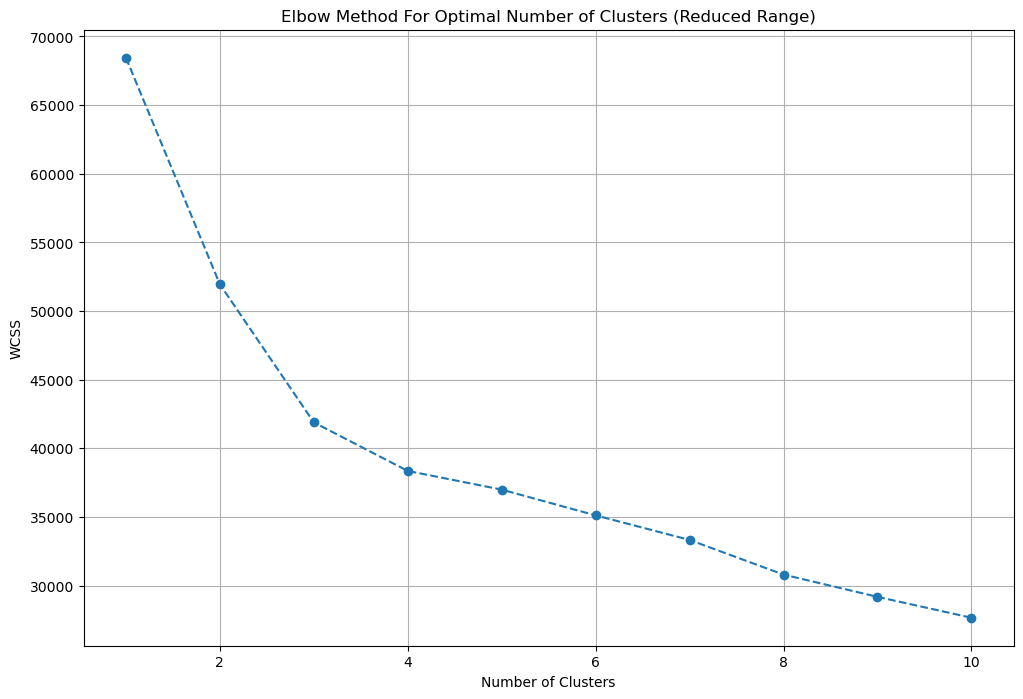

In [51]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1, 11), wcss_reduced, marker="o", linestyle="--")
plt.title("Elbow Method For Optimal Number of Clusters (Reduced Range)")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [53]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 18)","

In [54]:
# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [55]:
df = df.iloc[:, :-18]

In [56]:
df["furnishing_type"] = cluster_assignments

In [58]:
df.sample(5)[["furnishDetails", "furnishing_type"]]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
229,[],0
1610,"['1 Water Purifier', '5 Fan', '1 Exhaust Fan', '3 Geyser', '1 Stove', '19 Light', '1 Modular Kitchen', '1 Chimney', '4 AC', '7 Curtains', '3 Wardrobe', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine']",1
629,NaN,0
272,"['4 Wardrobe', '4 Geyser', '6 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
2273,NaN,0


# 5. Features

In [59]:
df[['society','features']].sample(5)

,society,features
1433,independent,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Park', 'Visitor Parking', 'Low Density Society']"
2271,shapoorji pallonji joyville gurugram,NaN
1963,kamal residence,"['Security / Fire Alarm', 'Lift(s)', 'Water Storage']"
304,godrej nature plus,NaN
733,railway officers rpf society,"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Lift(s)', 'Piped-gas', 'Club house / Community Center', 'Rain Water Harvesting']"


In [60]:
df["features"].isnull().sum()

635

In [62]:
import pandas as pd

app_df = pd.read_csv("appartments.csv")
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [63]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [64]:
temp_df = df[df['features'].isnull()]

In [65]:
temp_df.shape

(635, 26)

In [67]:
x = temp_df.merge(app_df, left_on="society", right_on="PropertyName", how="left")["TopFacilities"]

In [68]:
df.loc[temp_df.index, "features"] = x.values

In [69]:
df["features"].isnull().sum()

481

In [70]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [71]:
# Convert the string representation of lists in the 'features' column to actual lists
df["features_list"] = df["features"].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith("[") else [])

In [72]:
# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df["features_list"])

In [73]:
# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [74]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
262,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0
1882,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2282,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
1491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
1920,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [75]:
features_binary_df.shape

(3803, 130)

In [76]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

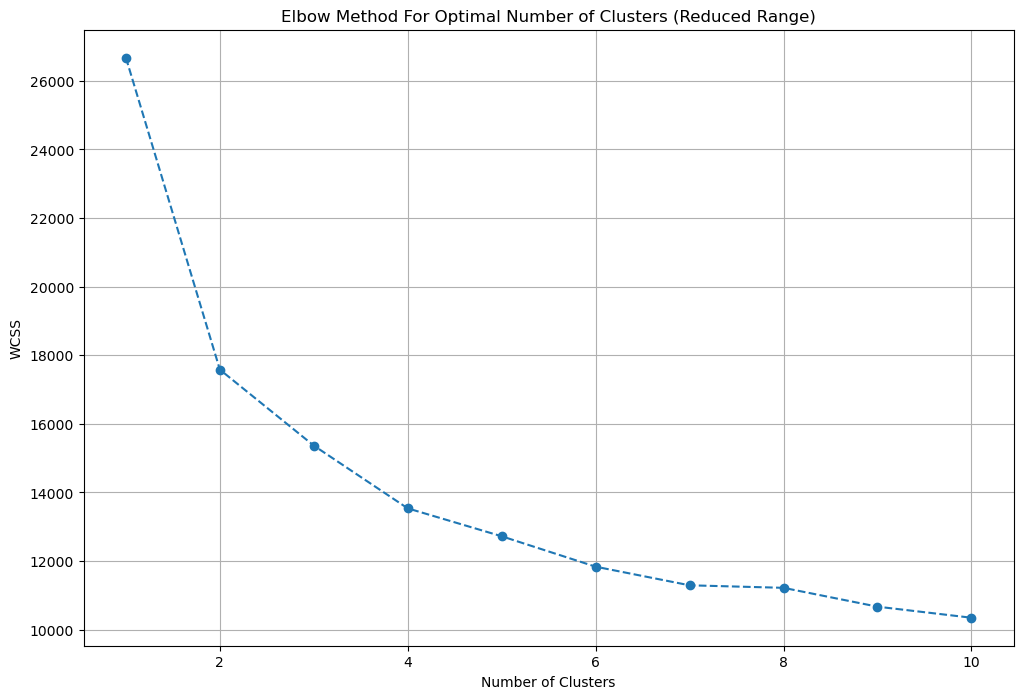

In [77]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1, 11), wcss_reduced, marker="o", linestyle="--")
plt.title("Elbow Method For Optimal Number of Clusters (Reduced Range)")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [78]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    "24/7 Power Backup": 8,
    "24/7 Water Supply": 4,
    "24x7 Security": 7,
    "ATM": 4,
    "Aerobics Centre": 6,
    "Airy Rooms": 8,
    "Amphitheatre": 7,
    "Badminton Court": 7,
    "Banquet Hall": 8,
    "Bar/Chill-Out Lounge": 9,
    "Barbecue": 7,
    "Basketball Court": 7,
    "Billiards": 7,
    "Bowling Alley": 8,
    "Business Lounge": 9,
    "CCTV Camera Security": 8,
    "Cafeteria": 6,
    "Car Parking": 6,
    "Card Room": 6,
    "Centrally Air Conditioned": 9,
    "Changing Area": 6,
    "Children's Play Area": 7,
    "Cigar Lounge": 9,
    "Clinic": 5,
    "Club House": 9,
    "Concierge Service": 9,
    "Conference room": 8,
    "Creche/Day care": 7,
    "Cricket Pitch": 7,
    "Doctor on Call": 6,
    "Earthquake Resistant": 5,
    "Entrance Lobby": 7,
    "False Ceiling Lighting": 6,
    "Feng Shui / Vaastu Compliant": 5,
    "Fire Fighting Systems": 8,
    "Fitness Centre / GYM": 8,
    "Flower Garden": 7,
    "Food Court": 6,
    "Foosball": 5,
    "Football": 7,
    "Fountain": 7,
    "Gated Community": 7,
    "Golf Course": 10,
    "Grocery Shop": 6,
    "Gymnasium": 8,
    "High Ceiling Height": 8,
    "High Speed Elevators": 8,
    "Infinity Pool": 9,
    "Intercom Facility": 7,
    "Internal Street Lights": 6,
    "Internet/wi-fi connectivity": 7,
    "Jacuzzi": 9,
    "Jogging Track": 7,
    "Landscape Garden": 8,
    "Laundry": 6,
    "Lawn Tennis Court": 8,
    "Library": 8,
    "Lounge": 8,
    "Low Density Society": 7,
    "Maintenance Staff": 6,
    "Manicured Garden": 7,
    "Medical Centre": 5,
    "Milk Booth": 4,
    "Mini Theatre": 9,
    "Multipurpose Court": 7,
    "Multipurpose Hall": 7,
    "Natural Light": 8,
    "Natural Pond": 7,
    "Park": 8,
    "Party Lawn": 8,
    "Piped Gas": 7,
    "Pool Table": 7,
    "Power Back up Lift": 8,
    "Private Garden / Terrace": 9,
    "Property Staff": 7,
    "RO System": 7,
    "Rain Water Harvesting": 7,
    "Reading Lounge": 8,
    "Restaurant": 8,
    "Salon": 8,
    "Sauna": 9,
    "Security / Fire Alarm": 9,
    "Security Personnel": 9,
    "Separate entry for servant room": 8,
    "Sewage Treatment Plant": 6,
    "Shopping Centre": 7,
    "Skating Rink": 7,
    "Solar Lighting": 6,
    "Solar Water Heating": 7,
    "Spa": 9,
    "Spacious Interiors": 9,
    "Squash Court": 8,
    "Steam Room": 9,
    "Sun Deck": 8,
    "Swimming Pool": 8,
    "Temple": 5,
    "Theatre": 9,
    "Toddler Pool": 7,
    "Valet Parking": 9,
    "Video Door Security": 9,
    "Visitor Parking": 7,
    "Water Softener Plant": 7,
    "Water Storage": 7,
    "Water purifier": 7,
    "Yoga/Meditation Area": 7,
}

In [80]:
# Calculate luxury score for each row
luxury_score = (
    features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1))

In [81]:
df["luxury_score"] = luxury_score

In [82]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,on request,sector 103,1.69,9146.0,1848.0,Super Built up area 1845(171.41 sq.m.),3,3,3+,not available,8.0,NaN,Relatively New,"['State bank ATM', 'Dr. Hitesh Dawar', 'Bhardwaj Hospital', 'R K Hospital Gurgaon', 'Shree Krishna Hospital Gurgaon', 'Prateek Nursing Home And Polyclinic', 'Chirag Hospital Pvt. Ltd', 'Esic Hospital Gurugram', 'Kr Dental Hub', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'Pizza Hut', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station', 'Basai dhankot railway station']","['3 Wardrobe', '6 Fan', '10 Light', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",1845.0,NaN,NaN,0,0,0,0,0,0,"[Feng Shui / Vaastu Compliant, Security / Fire Alarm, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Park, Visitor Parking]",49
1,house,independent,sector 40,5.00,21124.0,2367.0,Plot area 263(219.9 sq.m.),9,9,3+,"servant room,store room",3.0,North-West,Moderately Old,"['Huda city centre metro station', 'Axis bank ATM', 'State bank of india ATM', 'Icici bank ATM', 'Icici ATM', 'Citi bank ATM', 'Axis bank ATM', 'Hdfc ATM', 'Standard chartered ATM', 'Hdfc bank ATM', 'Axis bank ATM', 'Hdfc bank ATM', 'State bank of india ATM', 'Dispencery', 'Shivam Hospital Gurgaon', 'Fortis Memorial Research Institute Fortis Vivekanand Hospital', 'Dr. Naval Mendiratta', 'Centre For Sight Gurgaon Sector 29', 'Sukhmani Hospital Pvt. Ltd', 'Ahmed Hospital Multi Speciality', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Medanta', 'Gardian Pharmacy', 'City Medical', 'Gardian Pharmacy', 'Pernod Ricard Charitable Dispensary', 'IBP Petrol Pump', 'Bharat petroleum', 'Hdfc bank', 'Raj Restaurant', 'Fast food', 'Fast Food', 'Om Sweets', 'Bar and restaurant', 'Cafe Coffee Day', '32nd Milestone', 'Darbar', 'PWO house', 'Dhabba', 'St. Angels Jr', 'School of Inspired Leadership SOIL', 'CR Model Public School', 'Manav Rachna School', 'St. Angels Sr', 'Amity Global School', 'Salvan Public School', 'Stones2milestones', 'Manav Rachna Swimming Pool']","['10 Wardrobe', '21 Fan', '1 Exhaust Fan', '9 Geyser', '1 Washing Machine', '56 Light', '11 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Rain Water Harvesting']",NaN,263.0,NaN,0,1,1,0,0,1,"[Feng Shui / Vaastu Compliant, Private Garden / Terrace, High Ceiling Height, Maintenance Staff, Water Storage, Separate entry for servant room, No open drainage around, Park, Natural Light, Airy Rooms, Spacious Interiors, Rain Water Harvesting]",83
2,house,emaar mgf marbella,sector 66,NaN,NaN,NaN,Plot area 350(292.64 sq.m.)Built Up area: 6500 sq.yards (5434.83 sq.m.),4,4,3+,"pooja room,study room,servant room,store room",3.0,North,New Property,"['Sector 55-56 Rapid Metro Station', 'HUB 66', 'NH 48', 'Hasanpur', 'Gurugram University', 'Delhi Public School', 'Park Hospital', 'Indira Gandhi International Airport', 'Sealdah', 'Vatika Business Centre', 'The Oberoi', 'De Adventure Park', 'DLF Golf and Country Club', 'Tau DeviLal Sports Complex']",NaN,"['Security / Fire Alarm', 'Feng Shui / 

In [83]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(
    columns=[
        "nearbyLocations",
        "furnishDetails",
        "features",
        "features_list",
        "additionalRoom",
    ],
    inplace=True,
)

In [ ]:
df.sample(3)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3253,flat,viridian the plaza 106,sector 106,0.46,6571.0,700.0,Carpet area: 700 (65.03 sq.m.),1,1,1,18.0,NaN,New Property,NaN,NaN,700.0,0,0,0,0,0,0,104
2778,flat,ambience creacions,sector 22,2.40,17391.0,1380.0,Super Built up area 1380(128.21 sq.m.)Built Up area: 1200 sq.ft. (111.48 sq.m.)Carpet area: 900 sq.ft. (83.61 sq.m.),2,2,2,8.0,South-East,Relatively New,1380.0,1200.0,900.0,0,0,0,0,1,2,112
902,flat,apna enclave,sector 3,0.80,6153.0,1300.0,Super Built up area 1300(120.77 sq.m.)Built Up area: 1000 sq.ft. (92.9 sq.m.),3,3,1,0.0,NaN,Old Property,1300.0,1000.0,NaN,0,0,0,0,0,0,0


: 

In [85]:
df.shape

(3803, 23)

In [86]:
df.to_csv('gurgaon_properties_cleaned_v2.csv', index= False)